# BioCAS – Data Setup & Exploratory Analysis

**Este notebook hace tres cosas:**
1. Descarga el repositorio SPRSound de GitHub
2. Organiza los datos en la estructura `train/` (2022+2023+2024) y `test/` (2025)
3. Explora la distribución de clases para informar la estrategia de augmentation

> Correr una sola vez. Las celdas de descarga y organización tienen guards para no repetir trabajo.

## 0 · Dependencias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import collections
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from tqdm import tqdm
from pathlib import Path

DATA_DIR = Path("../data")

## 1 · EDA – Distribución de clases

Antes de definir cualquier estrategia de augmentation hay que ver cuántas muestras hay por clase **a nivel de evento** (que es la granularidad que usa la pipeline), no solo a nivel de grabación.

In [ ]:
# ── Normalización de strings (igual que en EventExtractionStage) ─────────────
EVENT_TYPE_NORM = {
    "normal":         "N",
    "rhonchi":        "R",
    "wheeze":         "W",
    "stridor":        "S",
    "coarse crackle": "CC",
    "fine crackle":   "FC",
    "wheeze&crackle": "WC",
    "wheeze+crackle": "WC",
}

CLASS_NAMES = {
    "N":  "Normal",
    "R":  "Rhonchi",
    "W":  "Wheeze",
    "S":  "Stridor",
    "CC": "Coarse Crackle",
    "FC": "Fine Crackle",
    "WC": "Wheeze+Crackle",
}

def scan_events(json_dir: Path):
    """Lee todos los JSONs de un directorio y devuelve una lista de dicts por evento."""
    rows = []
    for jpath in tqdm(sorted(json_dir.glob("*.json"))):
        try:
            ann = json.loads(jpath.read_text())
        except Exception:
            continue

        record_label = ann.get("record_annotation", "?")
        for ev in ann.get("event_annotation", []):
            raw   = ev.get("type", "").lower().strip()
            label = EVENT_TYPE_NORM.get(raw, raw.upper())
            dur_s = (int(ev.get("end", 0)) - int(ev.get("start", 0))) / 1000
            rows.append({
                "file":         jpath.stem,
                "record_label": record_label,
                "label":        label,
                "duration_s":   dur_s,
            })
    return rows

# Escanear train y test por separado
train_rows = scan_events(DATA_DIR / "train" / "json")
test_rows  = scan_events(DATA_DIR / "test"  / "json")

df_train = pd.DataFrame(train_rows)
df_test  = pd.DataFrame(test_rows)

print(f"Train events : {len(df_train):,}")
print(f"Test  events : {len(df_test):,}")
print()
print(df_train["label"].value_counts().rename("train").to_frame()
      .join(df_test["label"].value_counts().rename("test"), how="outer")
      .fillna(0).astype(int))

100%|██████████| 1309/1309 [00:05<00:00, 233.50it/s]

Train events : 19,872
Test  events : 4,706

       train  test
label             
CC       112    65
FC      1645  1885
N      16597  2175
R        210     7
S         66     8
W       1200   305
WC        42   261


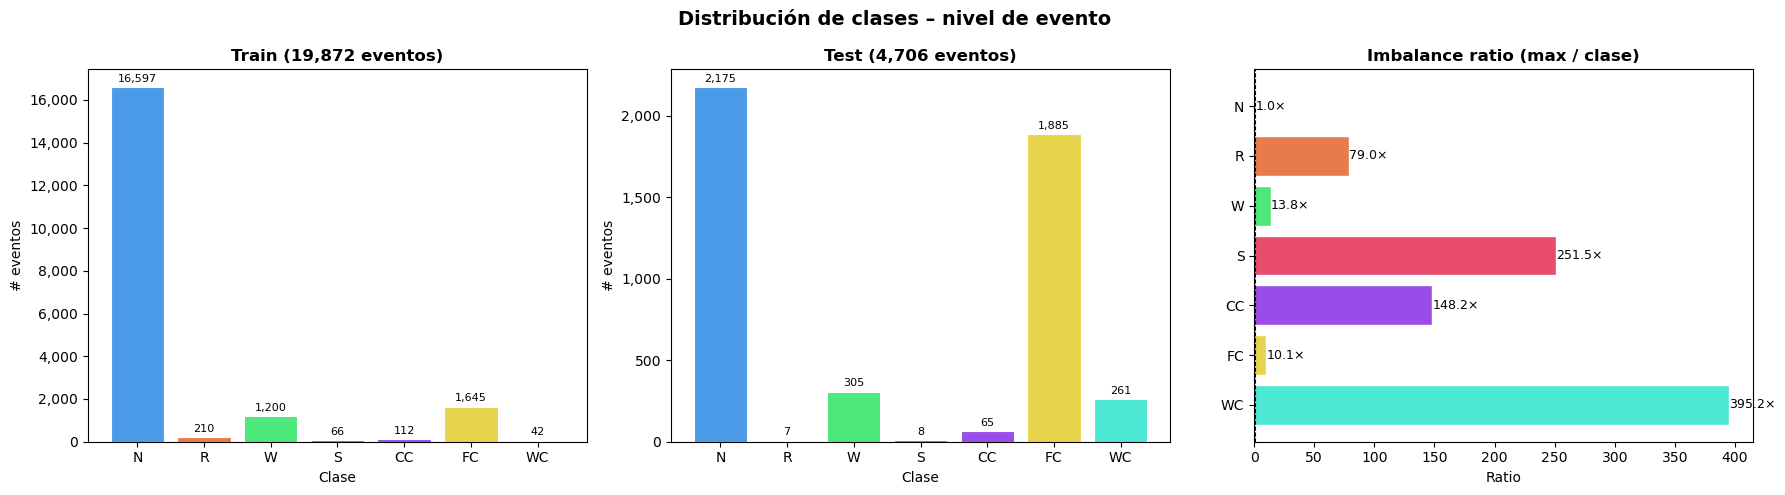

In [8]:
# ── Visualización ─────────────────────────────────────────────────────────────
ORDER  = ["N", "R", "W", "S", "CC", "FC", "WC"]
COLORS = ["#4C9BE8", "#E87B4C", "#4CE87B", "#E84C6B", "#9B4CE8", "#E8D44C", "#4CE8D4"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución de clases – nivel de evento", fontsize=14, fontweight="bold")

for ax, df, title in zip(axes[:2], [df_train, df_test], ["Train", "Test"]):
    counts = df["label"].value_counts().reindex(ORDER, fill_value=0)
    bars   = ax.bar(counts.index, counts.values, color=COLORS, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title} ({len(df):,} eventos)", fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("# eventos")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + max(counts)*0.01,
                    f"{int(h):,}", ha="center", va="bottom", fontsize=8)

# Imbalance ratio (max/min) – para informar la estrategia de augmentation
ax = axes[2]
train_counts = df_train["label"].value_counts().reindex(ORDER, fill_value=0)
max_cls = train_counts.max()
ratio   = (max_cls / train_counts.replace(0, np.nan)).fillna(0)
bars = ax.barh(ORDER[::-1], ratio.reindex(ORDER[::-1]), color=COLORS[::-1], edgecolor="white")
ax.set_title("Imbalance ratio (max / clase)", fontweight="bold")
ax.set_xlabel("Ratio")
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, ratio.reindex(ORDER[::-1])):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}×", va="center", fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\camsp\AppData\Local\Temp\ipykernel_39408\2914644447.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=ORDER, patch_artist=True, medianprops={"color": "black"})


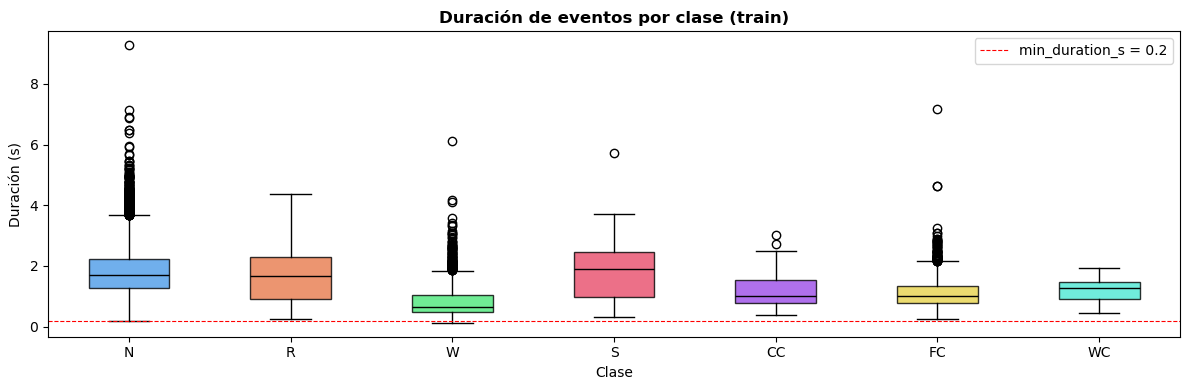

       count  mean  median   min   max
label                                 
N      16597  1.80    1.71  0.20  9.27
R        210  1.70    1.66  0.27  4.38
W       1200  0.85    0.64  0.13  6.12
S         66  1.87    1.91  0.33  5.71
CC       112  1.22    1.01  0.39  3.02
FC      1645  1.12    1.00  0.26  7.17
WC        42  1.20    1.27  0.46  1.92


In [9]:
# ── Distribución de duración de eventos por clase ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

data_by_class = [df_train[df_train["label"] == cls]["duration_s"].values for cls in ORDER]

bp = ax.boxplot(data_by_class, labels=ORDER, patch_artist=True, medianprops={"color": "black"})
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title("Duración de eventos por clase (train)", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Duración (s)")
ax.axhline(y=0.2, color="red", linestyle="--", linewidth=0.8, label="min_duration_s = 0.2")
ax.legend()
plt.tight_layout()
plt.show()

# Stats de duración
print(df_train.groupby("label")["duration_s"]
      .agg(["count", "mean", "median", "min", "max"])
      .reindex(ORDER)
      .round(2)
      .to_string())

In [10]:
# ── Resumen: cuánto augmentation necesita cada clase ─────────────────────────
# Esto es lo que hay que mirar ANTES de fijar los parámetros de la pipeline.

train_counts = df_train["label"].value_counts().reindex(ORDER, fill_value=0)
max_count    = train_counts.max()

summary = pd.DataFrame({
    "clase":        ORDER,
    "nombre":       [CLASS_NAMES[c] for c in ORDER],
    "n_eventos":    train_counts.values,
    "ratio_vs_max": (train_counts / max_count).round(3).values,
    "target_sqrt":  (np.sqrt(train_counts) / np.sqrt(train_counts).sum() * train_counts.sum()).round(0).astype(int).values,
    "necesita_aug": (max_count / train_counts.replace(0, np.nan)).fillna(0).round(1).values,
})

print(summary.to_string(index=False))
print()
print("→ 'necesita_aug' = cuántas veces hay que replicar esa clase para igualar a la mayoritaria.")
print("→ 'target_sqrt'  = objetivo con strategy='proportional' (más conservador).")

clase         nombre  n_eventos  ratio_vs_max  target_sqrt  necesita_aug
    N         Normal      16597         1.000        10505           1.0
    R        Rhonchi        210         0.013         1182          79.0
    W         Wheeze       1200         0.072         2825          13.8
    S        Stridor         66         0.004          662         251.5
   CC Coarse Crackle        112         0.007          863         148.2
   FC   Fine Crackle       1645         0.099         3307          10.1
   WC Wheeze+Crackle         42         0.003          528         395.2

→ 'necesita_aug' = cuántas veces hay que replicar esa clase para igualar a la mayoritaria.
→ 'target_sqrt'  = objetivo con strategy='proportional' (más conservador).


## 4 · Rutas para la pipeline

Una vez que analizaste la distribución, estas son las rutas para usar en `config/pipeline.yaml`.

In [11]:
train_wav  = (DATA_DIR / "train" / "wav").resolve()
train_json = (DATA_DIR / "train" / "json").resolve()
test_wav   = (DATA_DIR / "test"  / "wav").resolve()
test_json  = (DATA_DIR / "test"  / "json").resolve()

print("# Pegá esto en config/pipeline.yaml:")
print(f"""
data:
  raw_wav_dir:  "{train_wav}"
  raw_json_dir: "{train_json}"
  test_wav_dir:  "{test_wav}"
  test_json_dir: "{test_json}"
  output_dir:   "data/processed"
  task: "1-2"
""")

# Pegá esto en config/pipeline.yaml:

data:
  raw_wav_dir:  "C:\Users\camsp\Documents\Universidad\Semillero\BreathIA\workflow\data\train\wav"
  raw_json_dir: "C:\Users\camsp\Documents\Universidad\Semillero\BreathIA\workflow\data\train\json"
  test_wav_dir:  "C:\Users\camsp\Documents\Universidad\Semillero\BreathIA\workflow\data\test\wav"
  test_json_dir: "C:\Users\camsp\Documents\Universidad\Semillero\BreathIA\workflow\data\test\json"
  output_dir:   "data/processed"
  task: "1-2"

